In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [66]:
df = pd.read_csv("emissions.csv", sep =",")
n_cases = 4
n_materials = 6

df

,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,Initial_PES,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,"Climate change, incl biogenic carbon",9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,145511.865,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq
1,Freshwater aquatic ecotoxicity,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,4724.477,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,Marine aquatic ecotoxicity,49.000,36.171,48.220,35.815,46.110,34.364,48.612,35.925,6315.233,...,48.337,4.588,3.265,4.588,3.265,4.503,3.223,4.546,3.223,kg 1.4 DCB eq.
3,Terrestrial ecotoxicity,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,535417.090,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
4,Freshwater Eutrophication,0.500,0.369,0.492,0.366,0.471,0.351,0.496,0.367,37.767,...,0.558,0.025,0.018,0.025,0.018,0.024,0.018,0.025,0.018,kg P eq.
5,Marine Eutrophication,2.778,2.050,2.734,2.030,2.614,1.948,2.756,2.037,12.895,...,5.449,0.252,0.179,0.252,0.179,0.247,0.177,0.249,0.177,kg N eq.
6,Terrestrial Acidification,27.144,20.037,26.712,19.840,25.543,19.036,26.929,19.901,403.199,...,7.421,1.080,0.769,1.080,0.769,1.060,0.759,1.070,0.759,kg SO2 eq.
7,Photochemical Ozone Formation. Ecosystems,17.234,12.722,16.960,12.597,16.218,12.087,17.098,12.636,383.569,...,2.402,0.356,0.253,0.356,0.253,0.350,0.250,0.353,0.250,kg NOx eq.
8,lonizing Radiation,1.743,1.287,1.715,1.274,1.640,1.222,1.729,1.278,7296.447,...,8.412,1.519,1.081,1.519,1.081,1.491,1.067,1.505,1.067,kBq Co-60 eq.
9,"Human toxicity, cancer",181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,7198.569,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq


In [67]:
df = df[df.Category.isin(["Climate change, incl biogenic carbon",
"Freshwater aquatic ecotoxicity",
"Terrestrial ecotoxicity",
"Human toxicity, cancer",
"Human toxicity, non-cancer",
"Fossil depletion"])].reset_index()
df.Category = df.Category.str.replace(',', '\n')
df.Category = df.Category + " in " + df.Unit

In [68]:
materials = [string.rsplit("_", 1)[1] for string in df.columns[list(range(2, len(df.columns)-1, 8))]]
cases = [string.rsplit("_", 1)[0] for string in df.columns[list(range(2, 9, 2))]]

In [74]:
# Summed up cases
total_sums = df.Category
return_sums = df.Category
for i in range(2, 9, 2):
    total_sums = pd.concat([total_sums, 
                            df.iloc[:, [index for index in range(i, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)
    return_sums = pd.concat([return_sums, 
                            df.iloc[:, [index for index in range(i+1, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)

total_sums.columns.values[1:] = cases
return_sums.columns.values[1:] = cases

total_sums

,Category,Initial,Targeted,Incentive,Normal
0,Climate change\n incl biogenic carbon in kg CO...,161033.313,159268.089,145884.791,159256.618
1,Freshwater aquatic ecotoxicity in kg 1.4 DCB eq.,5081.376,5026.780,4593.833,5024.365
2,Terrestrial ecotoxicity in kg 1.4 DCB eq.,562958.737,556945.959,508966.393,556648.752
3,Human toxicity\n cancer in kg 1.4-DB eq,7714.671,7631.546,6979.165,7628.593
4,Human toxicity\n non-cancer in kg 1.4-DB eq,111027.753,109835.240,100360.351,109782.564
5,Fossil depletion in kg oil eq.,68321.431,67579.688,61844.399,67563.760


<Axes: xlabel='Category'>

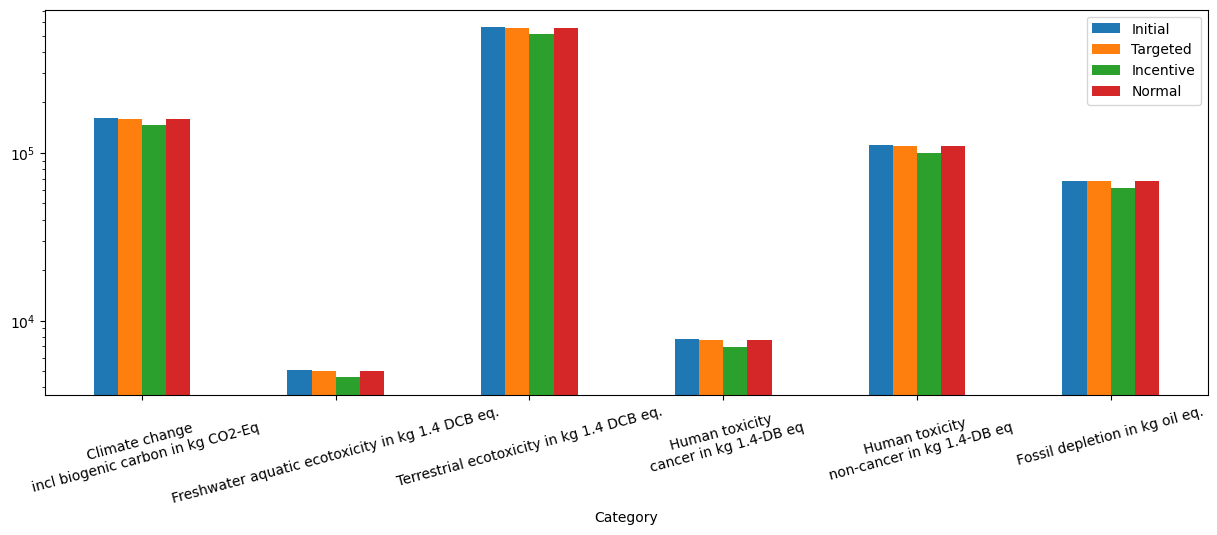

In [71]:
total_sums.plot.bar(logy = True, x='Category', stacked = False, rot=15, figsize=(15,5))

<Axes: xlabel='Category'>

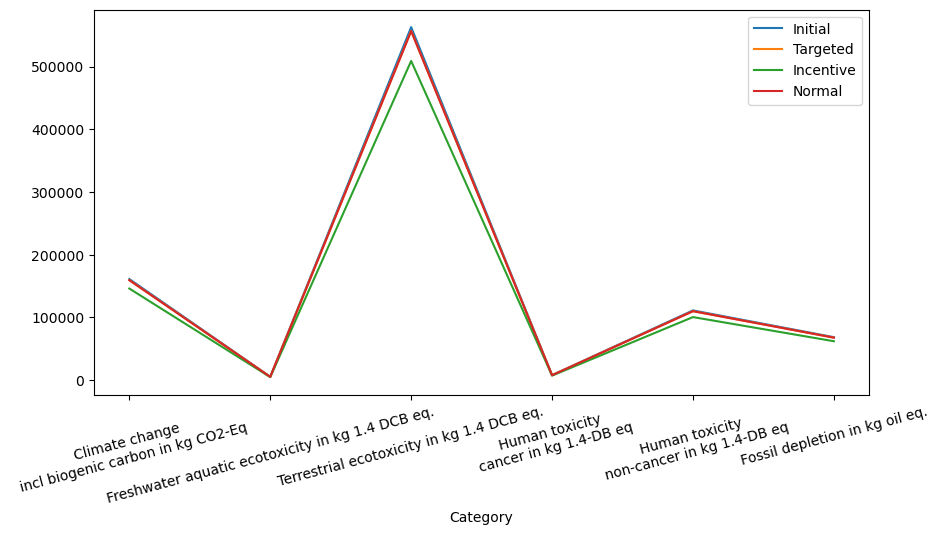

In [72]:
total_sums.plot(logy = False, x='Category', rot=15, figsize=(10,5))

<Axes: xlabel='Category'>

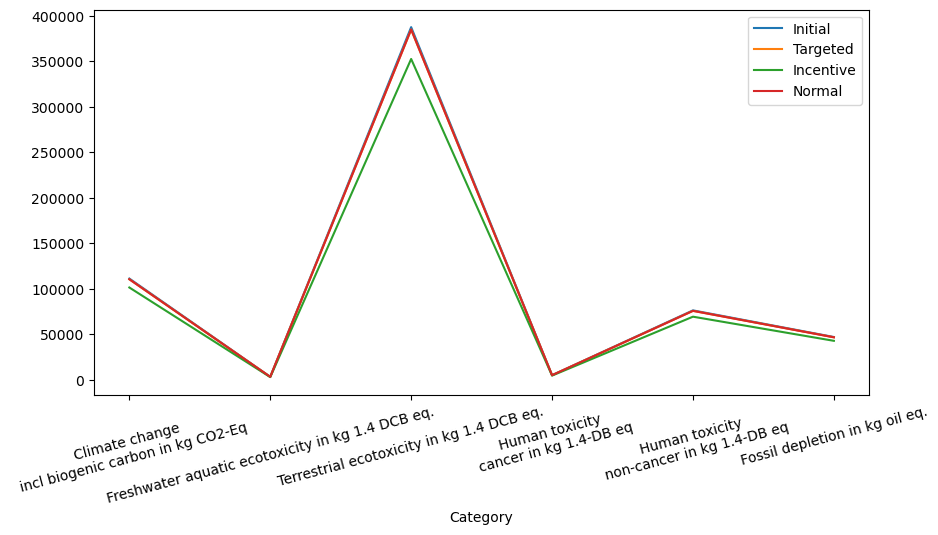

In [73]:
return_sums.plot(logy = False, x='Category', rot=15, figsize=(10,5))